In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [2]:
import os
import cv2
import numpy as np
from tqdm import tqdm

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score

from tensorflow.keras.applications import EfficientNetB0, MobileNetV3Small
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Concatenate, Input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

I0000 00:00:1774464951.307742 2982261 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
def extract_roi(img):
    h, w, _ = img.shape

    # tighter crop (focus more on brain center)
    start_x = int(w * 0.3)
    end_x   = int(w * 0.7)
    start_y = int(h * 0.3)
    end_y   = int(h * 0.7)

    roi = img[start_y:end_y, start_x:end_x]

    return roi

In [4]:
home = os.path.expanduser("~")
dataset_path = os.path.join(home, "hybrid_tumor_project", "extracted_data", "Figshare dataset")

IMG_SIZE = 224

images = []
labels = []

for label, folder in enumerate(sorted(os.listdir(dataset_path))):
    folder_path = os.path.join(dataset_path, folder)

    for file in tqdm(os.listdir(folder_path)):
        img_path = os.path.join(folder_path, file)

        img = cv2.imread(img_path)

        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = extract_roi(img)

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = preprocess_input(img)

            images.append(img)
            labels.append(label)

X = np.array(images, dtype=np.float32)
y = np.array(labels)

print("Dataset:", X.shape)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 930/930 [00:02<00:00, 421.08it/s]


Dataset: (3064, 224, 224, 3)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [6]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

In [7]:
datagen = ImageDataGenerator(
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True
)

train_gen = datagen.flow(X_train, y_train, batch_size=4)

In [8]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

In [9]:
from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, Dense, Reshape, Multiply, Conv2D, Add, Activation, Concatenate, Lambda

def cbam_block(feature_map):

    channel = feature_map.shape[-1]

    # Channel Attention
    avg_pool = GlobalAveragePooling2D()(feature_map)
    max_pool = GlobalMaxPooling2D()(feature_map)

    avg_pool = Dense(channel // 8, activation='relu')(avg_pool)
    avg_pool = Dense(channel, activation='sigmoid')(avg_pool)

    max_pool = Dense(channel // 8, activation='relu')(max_pool)
    max_pool = Dense(channel, activation='sigmoid')(max_pool)

    channel_attention = Add()([avg_pool, max_pool])
    channel_attention = Activation('sigmoid')(channel_attention)

    channel_attention = Reshape((1,1,channel))(channel_attention)
    feature_map = Multiply()([feature_map, channel_attention])

    #  FIXED Spatial Attention (NO tf ops)
    avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(feature_map)
    max_pool = Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(feature_map)

    concat = Concatenate(axis=-1)([avg_pool, max_pool])

    spatial_attention = Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(concat)

    feature_map = Multiply()([feature_map, spatial_attention])

    return feature_map

In [10]:
tf.keras.backend.clear_session()

In [11]:
import gc
import tensorflow as tf

tf.keras.backend.clear_session()
gc.collect()

0

In [12]:
input_layer = Input(shape=(224,224,3))

# EfficientNet branch
eff_base = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=input_layer)

for layer in eff_base.layers[:-80]:
    layer.trainable = False

eff_out = GlobalAveragePooling2D()(eff_base.output)

# MobileNet branch
mob_base = MobileNetV3Small(weights='imagenet', include_top=False, input_tensor=input_layer)

for layer in mob_base.layers[:-50]:
    layer.trainable = False

mob_out = GlobalAveragePooling2D()(mob_base.output)

#  Feature Fusion
# reshape for CBAM
combined = Concatenate()([eff_out, mob_out])
combined = tf.keras.layers.Reshape((1,1,combined.shape[-1]))(combined)

#  APPLY CBAM
combined = cbam_block(combined)

# flatten back
combined = GlobalAveragePooling2D()(combined)

# Classifier
x = Dense(256, activation='relu')(combined)
x = Dropout(0.5)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(3, activation='softmax')(x)

model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

E0000 00:00:1774464973.640711 2982261 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
I0000 00:00:1774464973.640802 2982261 cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES="-1"
I0000 00:00:1774464973.640865 2982261 cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to -1 - this hides all GPUs from CUDA
I0000 00:00:1774464973.640889 2982261 cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
I0000 00:00:1774464973.640893 2982261 cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: srmap
I0000 00:00:1774464973.640899 2982261 cuda_diagnostics.cc:183] hostname: srmap
I0000 00:00:1774464973.641102 2982261 cuda_diagnostics.cc:190] libcuda reported version is: 555.42.2
I0000 00:00:1774464973.641141 2982261 cuda_diagnostics.cc:194] kernel reported ve

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 7,224,009 (27.56 MB)

 Trainable params: 6,203,130 (23.66 MB)

 Non-trainable params: 1,020,879 (3.89 MB)

In [13]:
history = model.fit(
    train_gen,
    validation_data=(X_test, y_test),
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

Epoch 1/20


I0000 00:00:1774464977.375882 2982261 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


613/613 ━━━━━━━━━━━━━━━━━━━━ 208s 269ms/step - accuracy: 0.5757 - loss: 0.8971 - val_accuracy: 0.8532 - val_loss: 0.4642 - learning_rate: 5.0000e-05
Epoch 2/20
613/613 ━━━━━━━━━━━━━━━━━━━━ 153s 250ms/step - accuracy: 0.7768 - loss: 0.5905 - val_accuracy: 0.8646 - val_loss: 0.3273 - learning_rate: 5.0000e-05
Epoch 3/20
613/613 ━━━━━━━━━━━━━━━━━━━━ 156s 254ms/step - accuracy: 0.8091 - loss: 0.4803 - val_accuracy: 0.9119 - val_loss: 0.2057 - learning_rate: 5.0000e-05
Epoch 4/20
613/613 ━━━━━━━━━━━━━━━━━━━━ 151s 246ms/step - accuracy: 0.8417 - loss: 0.4143 - val_accuracy: 0.9266 - val_loss: 0.1821 - learning_rate: 5.0000e-05
Epoch 5/20
613/613 ━━━━━━━━━━━━━━━━━━━━ 150s 244ms/step - accuracy: 0.8556 - loss: 0.3620 - val_accuracy: 0.9380 - val_loss: 0.1473 - learning_rate: 5.0000e-05
Epoch 6/20
613/613 ━━━━━━━━━━━━━━━━━━━━ 159s 259ms/step - accuracy: 0.8849 - loss: 0.3073 - val_accuracy: 0.9429 - val_loss: 0.1486 - learning_rate: 5.0000e-05
Epoch 7/20
613/613 ━━━━━━━━━━━━━━━━━━━━ 153s 250ms/

In [14]:
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

print("Hybrid Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 588ms/step
Hybrid Accuracy: 0.9690048939641109
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       285
           1       0.93      0.94      0.93       142
           2       0.98      0.98      0.98       186

    accuracy                           0.97       613
   macro avg       0.96      0.97      0.96       613
weighted avg       0.97      0.97      0.97       613



In [15]:
classes = sorted(os.listdir(dataset_path))
classes = [c.replace("_tumor","") for c in classes]

print("Classes:", classes)

Classes: ['Glioma', 'Meningioma', 'Pituitary']


In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.efficientnet import preprocess_input

img_path = os.path.join(home,"hybrid_tumor_project", "866.jpg") 

# Load image
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224,224))

# Preprocess (IMPORTANT: same as training)
img_input = preprocess_input(img.copy())

# Add batch dimension
img_input = np.expand_dims(img_input, axis=0)

# Predict
prediction = model.predict(img_input)
pred_class = np.argmax(prediction)

# Print results
print("Prediction Probabilities:", prediction)
print("Predicted Class:", classes[pred_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction Probabilities: [[8.99226725e-01 1.00737095e-01 3.62664032e-05]]
Predicted Class: Glioma


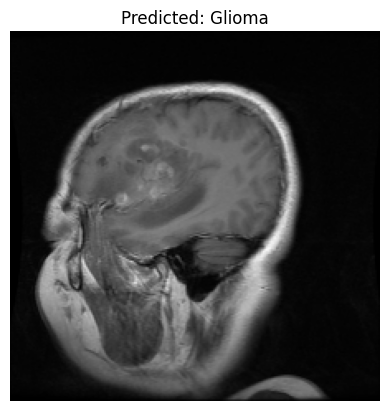

In [17]:
plt.imshow(img)
plt.title(f"Predicted: {classes[pred_class]}")
plt.axis("off")
plt.show()

In [18]:
confidence = np.max(prediction) * 100
print(f"Confidence: {confidence:.2f}%")

Confidence: 89.92%


In [19]:
print("ROI Hybrid Accuracy:", accuracy_score(y_test, y_pred))

ROI Hybrid Accuracy: 0.9690048939641109


In [20]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [21]:
def get_gradcam_heatmap(model, img_array, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)
    return heatmap

In [22]:
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224,224))

img_array = np.expand_dims(img, axis=0)
img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)

heatmap = get_gradcam_heatmap(model, img_array, "top_conv")

/home/dgxuser45/.local/lib/python3.11/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


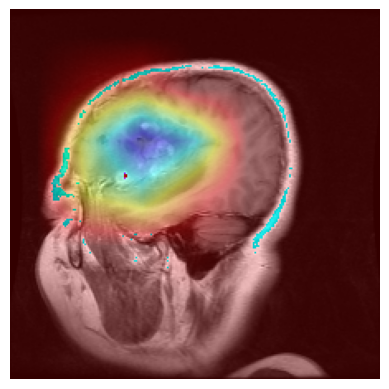

In [23]:
heatmap = cv2.resize(heatmap, (224,224))
heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + img

plt.imshow(superimposed_img.astype("uint8"))
plt.axis("off")
plt.show()

In [24]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 482ms/step


In [25]:
from sklearn.metrics import accuracy_score, classification_report

print("CBAM Hybrid Accuracy:", accuracy_score(y_test, y_pred_classes))

CBAM Hybrid Accuracy: 0.9690048939641109


In [26]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_classes))


Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       285
           1       0.93      0.94      0.93       142
           2       0.98      0.98      0.98       186

    accuracy                           0.97       613
   macro avg       0.96      0.97      0.96       613
weighted avg       0.97      0.97      0.97       613



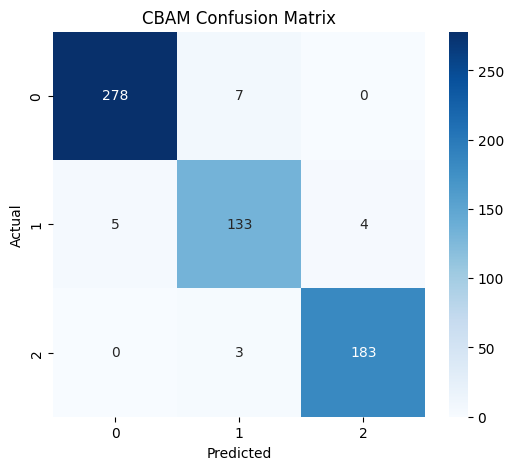

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CBAM Confusion Matrix")
plt.show()

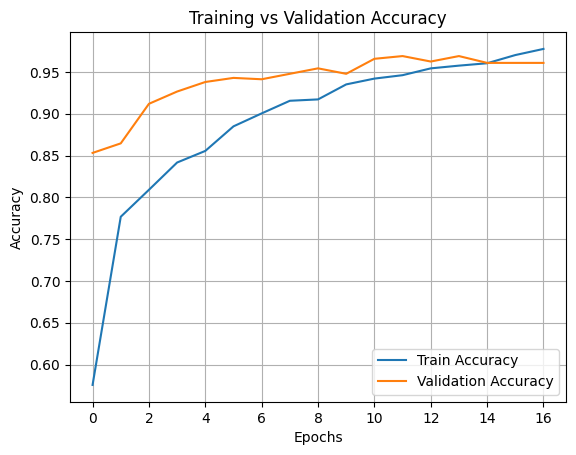

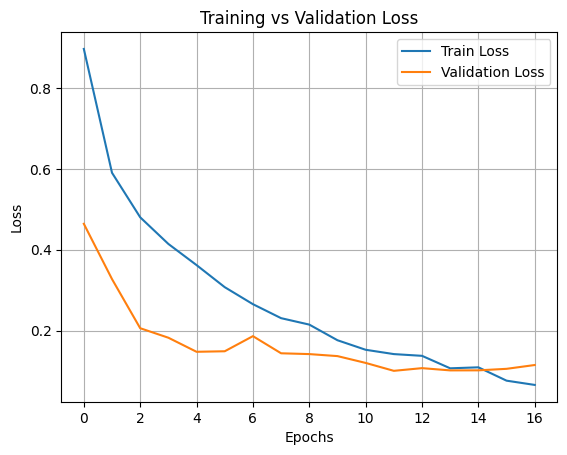

In [28]:
import matplotlib.pyplot as plt

# Accuracy Graph
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

# Loss Graph
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()